# Pembuktian: Mean-Variance Risk Aversion + Risk Tolerance vs Model Pembanding

Empat model dibandingkan pada data (mu, Sigma) dan parameter PSO yang sama dengan notebook utama:

| Model | Fungsi objektif (maksimalkan) | Keterangan |
|---|---|---|
| **MV Biasa** | $2\mu^Tw - w^T\Sigma w$ | tanpa parameter preferensi investor (setara $t=1$) |
| **MV RT** | $2t\,\mu^Tw - w^T\Sigma w$ | hanya risk tolerance $t$ |
| **MV RA** | $2\mu^Tw - \frac{1}{t}w^T\Sigma w$ | hanya risk aversion $1/t$ |
| **MV RA+RT** | $2t\,\mu^Tw - \frac{1}{t}w^T\Sigma w$ | model yang dipakai di skripsi |

Semua dibatasi long-only dan $\sum w_i = 1$. Tiap model diselesaikan dengan PSO (banyak run, seed sama antar model)
lalu dibandingkan dengan solusi eksak (SLSQP) dan frontier Markowitz klasik sebagai patokan.

**Catatan penting sebelum membaca hasil:** secara matematis, $\max\; 2t\mu^Tw - \frac1t w^T\Sigma w$ sama dengan
$\max\; 2t^2\mu^Tw - w^T\Sigma w$ (dikali $t$). Jadi MV RT dan MV RA menghasilkan portofolio optimal yang *identik* untuk $t$ yang sama,
dan MV RA+RT hanyalah MV RT dengan tolerance efektif $\tau = t^2$. Sel *Uji Kesetaraan* di bawah membuktikan ini secara numerik.
Artinya keunggulan RA+RT tidak bisa diklaim dari "frontier-nya lebih tinggi", tapi dari sifat lain
(cakupan frontier, resolusi/kehalusan pergerakan portofolio terhadap $t$, kestabilan & kecepatan PSO). Metrik-metrik itu yang diukur di sini.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ---- Data (sama dengan notebook utama) ----
df_selected   = pd.read_csv("saham_terpilih.csv")
df_cov_matrix = pd.read_csv("covariance_matrix.csv", index_col=0)

mu          = df_selected['Expected Return'].values.reshape(-1, 1)
sigma       = df_cov_matrix.values
stock_names = df_selected['Saham'].tolist()
n           = len(mu)
mu1d        = mu.ravel()

# ---- Parameter PSO (sama dengan notebook utama) ----
num_particles  = 100
num_iterations = 1000
w_inertia      = 0.75
c1 = c2        = 2

# ---- Grid t (sama dengan notebook utama) ----
t_grid = np.arange(0.001, 0.5, 0.01)
N_RUN  = 10          # jumlah run PSO per (model, t) untuk uji kestabilan
print(f"{n} saham | {len(t_grid)} nilai t | {N_RUN} run PSO per titik")

10 saham | 50 nilai t | 10 run PSO per titik


## 1. Definisi model
Semua model ditulis sebagai $f(w)=a\,\mu^Tw - b\,w^T\Sigma w$; yang membedakan hanya $(a,b)$ sebagai fungsi $t$.

In [2]:
MODELS = {
    "MV Biasa": lambda t: (2.0,      1.0),
    "MV RT":    lambda t: (2.0 * t,  1.0),
    "MV RA":    lambda t: (2.0,      1.0 / t),
    "MV RA+RT": lambda t: (2.0 * t,  1.0 / t),
}
PARAM_MODELS = ["MV RT", "MV RA", "MV RA+RT"]   # model yang punya parameter t
COLORS = {"MV Biasa": "gray", "MV RT": "tab:blue", "MV RA": "tab:orange", "MV RA+RT": "tab:red"}

## 2. PSO (vektorisasi, logika sama dengan notebook utama) dan solver eksak sebagai patokan

In [3]:
def pso(a, b, seed, lam=1.0):
    # PSO long-only. Return: bobot terbaik, skor terbaik, jumlah iterasi.
    rng = np.random.default_rng(seed)

    def f(W):
        # penalti (e'w-1)^2 selalu 0 karena W dinormalisasi tiap iterasi
        return (a * (W @ mu1d)
                - b * np.einsum('ij,jk,ik->i', W, sigma, W)
                - lam * (W.sum(1) - 1) ** 2)

    W = rng.dirichlet(np.ones(n), size=num_particles)
    V = rng.uniform(-1, 1, (num_particles, n))
    pbp, pbs = W.copy(), f(W)
    gbp, gbs = pbp[np.argmax(pbs)].copy(), pbs.max()
    prev = -np.inf
    it_used = 0

    for it in range(num_iterations):
        r1, r2 = rng.random(2)
        V = w_inertia * V + c1 * r1 * (pbp - W) + c2 * r2 * (gbp - W)
        W = np.clip(W + V, 0, 1)
        W = W / W.sum(1, keepdims=True)

        s = f(W)
        m = s > pbs
        pbs[m], pbp[m] = s[m], W[m]
        if pbs.max() > gbs:
            prev, gbs = gbs, pbs.max()
            gbp = pbp[np.argmax(pbs)].copy()

        it_used = it + 1
        if abs(gbs - prev) < 1e-16:      # kriteria henti sama seperti notebook utama
            break
    return gbp, gbs, it_used


_s2 = np.mean(np.diag(sigma))

def exact_opt(a, b):
    # Solusi eksak (convex QP, long-only, sum=1) sebagai patokan kebenaran.
    sc  = 1.0 / (_s2 * b)                 # skala agar objektif O(1); argmax tidak berubah
    obj = lambda w: -sc * (a * mu1d @ w - b * w @ sigma @ w)
    jac = lambda w: -sc * (a * mu1d - 2 * b * sigma @ w)
    res = minimize(obj, np.ones(n) / n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)] * n,
                   constraints=({'type': 'eq', 'fun': lambda w: w.sum() - 1,
                                 'jac': lambda w: np.ones(n)},),
                   options={'ftol': 1e-15, 'maxiter': 2000})
    return res.x


def min_var_at(R):
    # Varians minimum pada target return R (frontier Markowitz klasik).
    res = minimize(lambda w: w @ sigma @ w / _s2, np.ones(n) / n, method='SLSQP',
                   bounds=[(0, 1)] * n,
                   constraints=({'type': 'eq', 'fun': lambda w: w.sum() - 1},
                                {'type': 'eq', 'fun': lambda w: mu1d @ w - R}),
                   options={'ftol': 1e-15, 'maxiter': 2000})
    return (res.fun * _s2) if res.success else np.nan


# Frontier klasik (patokan): dari GMV sampai return maksimum
w_gmv = minimize(lambda w: w @ sigma @ w / _s2, np.ones(n) / n, method='SLSQP',
                 bounds=[(0, 1)] * n,
                 constraints=({'type': 'eq', 'fun': lambda w: w.sum() - 1},)).x
R_grid   = np.linspace(mu1d @ w_gmv, mu1d.max() * 0.999, 80)
V_front  = np.array([min_var_at(R) for R in R_grid])
print("Frontier klasik siap:", np.isfinite(V_front).sum(), "titik")

Frontier klasik siap: 80 titik


## 3. Uji kesetaraan matematis (solusi eksak)
Membuktikan bahwa RT = RA untuk $t$ yang sama, dan RA+RT($t$) = RT($\tau=t^2$).

In [4]:
d_rt_ra, d_rart_rt2 = [], []
for t in t_grid:
    w_rt   = exact_opt(*MODELS["MV RT"](t))
    w_ra   = exact_opt(*MODELS["MV RA"](t))
    w_rart = exact_opt(*MODELS["MV RA+RT"](t))
    w_rt2  = exact_opt(*MODELS["MV RT"](t ** 2))
    d_rt_ra.append(np.abs(w_rt - w_ra).max())
    d_rart_rt2.append(np.abs(w_rart - w_rt2).max())

print(f"max |w_RT(t)  - w_RA(t)|        = {max(d_rt_ra):.2e}   (0 => identik)")
print(f"max |w_RA+RT(t) - w_RT(t^2)|    = {max(d_rart_rt2):.2e}   (0 => identik)")

max |w_RT(t)  - w_RA(t)|        = 2.60e-08   (0 => identik)
max |w_RA+RT(t) - w_RT(t^2)|    = 2.59e-08   (0 => identik)


## 4. Eksperimen PSO: 4 model x grid t x N_RUN run
Seed dipakai sama antar model (common random numbers) supaya perbandingan adil.

In [5]:
records, W_mean = [], {}
t_start = time.time()

for name, coef in MODELS.items():
    ts = [None] if name == "MV Biasa" else list(t_grid)
    for t in ts:
        tt   = 1.0 if t is None else t
        a, b = coef(tt)
        w_ex = exact_opt(a, b)

        ws = []
        for run in range(N_RUN):
            seed = 1000 * run + (0 if t is None else int(round(t * 1000)))
            t0 = time.perf_counter()
            w, sc, it = pso(a, b, seed)
            dt = time.perf_counter() - t0
            mup, varp = float(mu1d @ w), float(w @ sigma @ w)
            vmin = min_var_at(mup)
            records.append(dict(
                model=name, t=t, run=run, iterasi=it, waktu=dt,
                mup=mup, varp=varp, sigp=np.sqrt(varp), rasio=mup / np.sqrt(varp),
                err_L1=np.abs(w - w_ex).sum(),
                gap_frontier=(varp - vmin) / vmin if np.isfinite(vmin) else np.nan))
            ws.append(w)
        W_mean[(name, t)] = np.mean(ws, axis=0)

df_all = pd.DataFrame(records)
print(f"Selesai dalam {time.time() - t_start:.1f} detik, {len(df_all)} run PSO")

Selesai dalam 171.6 detik, 1510 run PSO


## 5. Ringkasan per model

Kolom:
- **Rentang return / sigma** : seberapa lebar frontier yang terjangkau oleh grid $t$
- **Rasio maks** : return-to-risk tertinggi yang ditemukan sepanjang grid
- **Portofolio unik** : berapa banyak bobot yang benar-benar berbeda ($L_1 > 10^{-3}$) dari `len(t_grid)` nilai $t$ (resolusi parameter)
- **CV jarak** : keseragaman jarak antar portofolio berturutan (kecil = pergerakan halus/merata)
- **Err bobot vs eksak, Gap ke frontier, Iterasi, Waktu** : kualitas dan biaya PSO (rata-rata seluruh run)

In [6]:
def unique_count(model):
    ws = [W_mean[(model, t)] for t in (t_grid if model != "MV Biasa" else [None])]
    d  = [np.abs(ws[i] - ws[i - 1]).sum() for i in range(1, len(ws))]
    cnt = 1 + sum(x > 1e-3 for x in d)
    cv  = np.std(d) / np.mean(d) if len(d) and np.mean(d) > 0 else np.nan
    return cnt, cv

rows = []
for name in MODELS:
    g  = df_all[df_all.model == name]
    gm = g.groupby('t', dropna=False)[['mup', 'sigp', 'rasio']].mean()
    cnt, cv = unique_count(name)
    best = gm['rasio'].idxmax()
    rows.append({
        "Model": name,
        "Rentang return":  f"{gm.mup.min():.6f} - {gm.mup.max():.6f}",
        "Rentang sigma":   f"{gm.sigp.min():.5f} - {gm.sigp.max():.5f}",
        "Rasio maks":      gm.rasio.max(),
        "t @ rasio maks":  best,
        "Portofolio unik": cnt,
        "CV jarak":        cv,
        "Err bobot vs eksak (L1)": g.err_L1.mean(),
        "Gap ke frontier": g.gap_frontier.mean(),
        "Std rasio antar-run": g.groupby('t', dropna=False).rasio.std().mean(),
        "Iterasi rata2":   g.iterasi.mean(),
        "Waktu/run (s)":   g.waktu.mean(),
    })
df_sum = pd.DataFrame(rows).set_index("Model")
pd.set_option('display.width', 250); pd.set_option('display.max_columns', None)
display(df_sum.style.format({"Rasio maks": "{:.5f}", "t @ rasio maks": "{:.3f}", "CV jarak": "{:.3f}",
                             "Err bobot vs eksak (L1)": "{:.2e}", "Gap ke frontier": "{:.2e}",
                             "Std rasio antar-run": "{:.2e}", "Iterasi rata2": "{:.0f}",
                             "Waktu/run (s)": "{:.4f}"}, na_rep="-"))
df_sum.to_csv("perbandingan_model_ringkasan.csv")

,Rentang return,Rentang sigma,Rasio maks,t @ rasio maks,Portofolio unik,CV jarak,Err bobot vs eksak (L1),Gap ke frontier,Std rasio antar-run,Iterasi rata2,Waktu/run (s)
Model,,,,,,,,,,,
MV Biasa,0.019269 - 0.019269,0.04548 - 0.04548,0.42370,-,1,-,1.85e-13,2.10e-16,0.00e+00,1000,0.1541
MV RT,0.006260 - 0.019269,0.01675 - 0.04548,0.55552,0.041,26,1.419,2.03e-02,1.53e-03,1.71e-03,630,0.0967
MV RA,0.006260 - 0.019269,0.01675 - 0.04548,0.55552,0.041,24,1.475,1.93e-02,1.26e-03,1.70e-03,649,0.1064
MV RA+RT,0.005940 - 0.019269,0.01674 - 0.04548,0.55555,0.201,50,0.276,3.35e-02,1.81e-03,3.62e-03,285,0.0462


## 6. Visualisasi

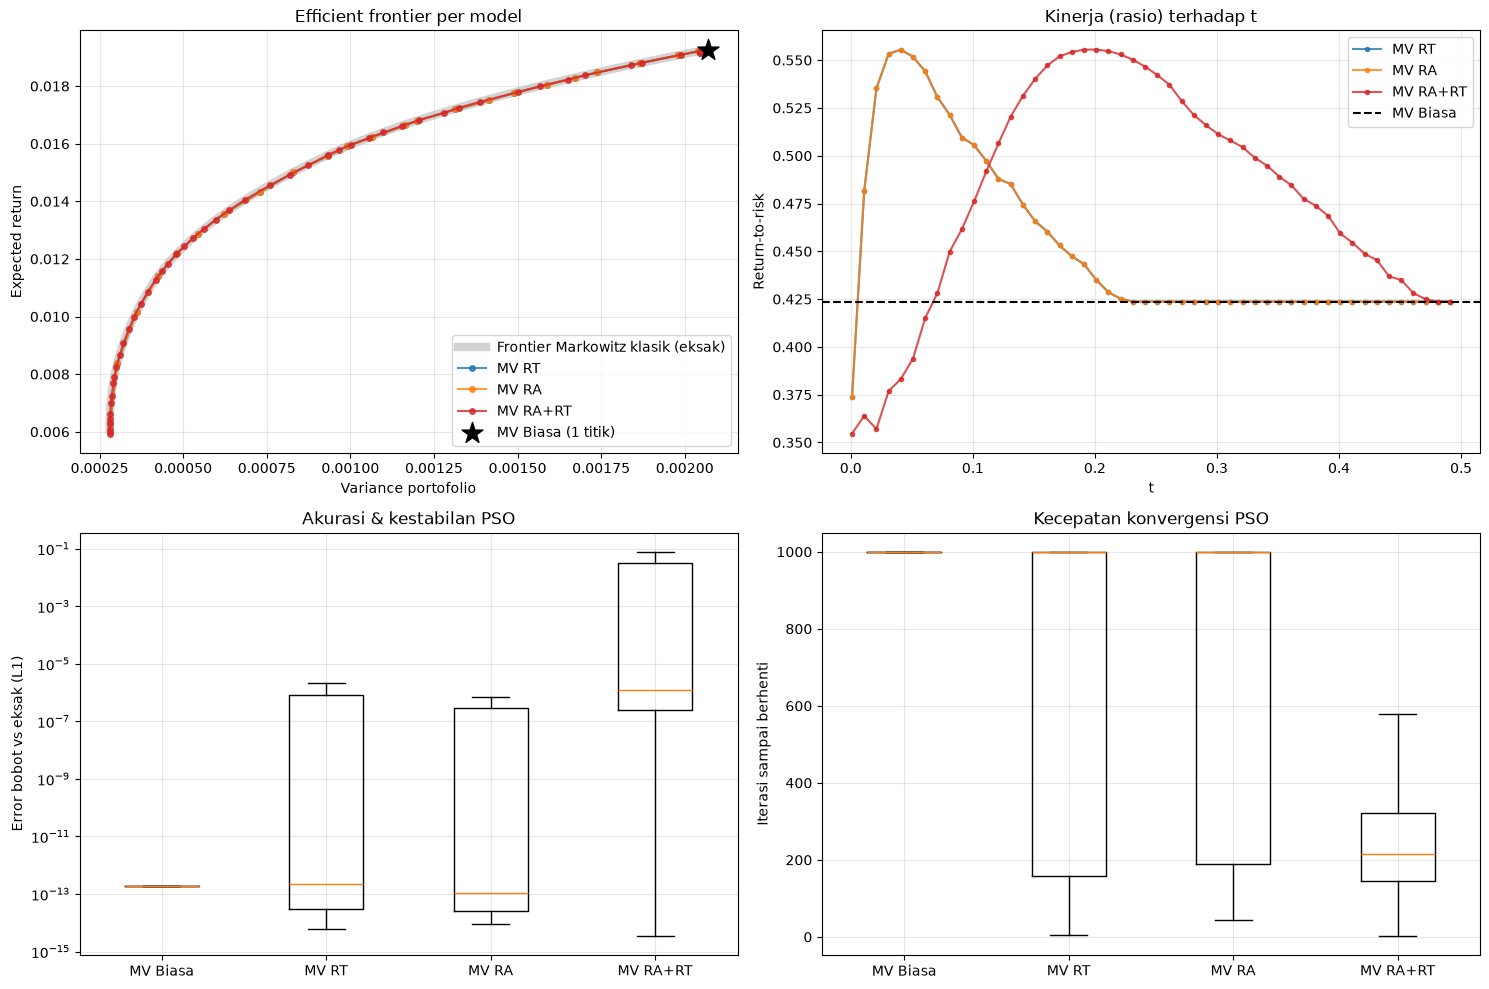

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# (a) Frontier
a0 = ax[0, 0]
a0.plot(V_front, R_grid, color='lightgray', lw=6, label='Frontier Markowitz klasik (eksak)', zorder=1)
for name in PARAM_MODELS:
    g = df_all[df_all.model == name].groupby('t')[['varp', 'mup']].mean()
    a0.plot(g.varp, g.mup, 'o-', ms=4, color=COLORS[name], label=name, alpha=.8, zorder=2)
gb = df_all[df_all.model == "MV Biasa"][['varp', 'mup']].mean()
a0.scatter(gb.varp, gb.mup, marker='*', s=250, color='black', label='MV Biasa (1 titik)', zorder=3)
a0.set_xlabel('Variance portofolio')
a0.set_ylabel('Expected return')
a0.set_title('Efficient frontier per model')
a0.legend()
a0.grid(alpha=.3)

# (b) Rasio vs t
a1 = ax[0, 1]
for name in PARAM_MODELS:
    g = df_all[df_all.model == name].groupby('t').rasio.mean()
    a1.plot(g.index, g.values, 'o-', ms=3, color=COLORS[name], label=name, alpha=.8)
a1.axhline(df_all[df_all.model == "MV Biasa"].rasio.mean(), color='black', ls='--', label='MV Biasa')
a1.set_xlabel('t')
a1.set_ylabel('Return-to-risk')
a1.set_title('Kinerja (rasio) terhadap t')
a1.legend()
a1.grid(alpha=.3)

# (c) Kestabilan PSO
a2 = ax[1, 0]
data_err = [df_all[df_all.model == m].err_L1.dropna().values for m in MODELS]
a2.boxplot(data_err, tick_labels=list(MODELS), showfliers=False)
a2.set_yscale('log')
a2.set_ylabel('Error bobot vs eksak (L1)')
a2.set_title('Akurasi & kestabilan PSO')
a2.grid(alpha=.3)

# (d) Iterasi
a3 = ax[1, 1]
data_iter = [df_all[df_all.model == m].iterasi.dropna().values for m in MODELS]
a3.boxplot(data_iter, tick_labels=list(MODELS), showfliers=False)
a3.set_ylabel('Iterasi sampai berhenti')
a3.set_title('Kecepatan konvergensi PSO')
a3.grid(alpha=.3)

plt.tight_layout()
plt.savefig("perbandingan_model.png", dpi=200)
plt.show()

## 7. Rekap kemenangan per kriteria (hanya model ber-parameter)
Peringkat 1 = terbaik. Nilai imbang diberi peringkat sama.

In [9]:
crit = {   # kriteria: (kolom, True bila lebih besar lebih baik)
    "Rasio maks":               ("Rasio maks", True),
    "Portofolio unik":          ("Portofolio unik", True),
    "CV jarak":                 ("CV jarak", False),
    "Err bobot vs eksak":       ("Err bobot vs eksak (L1)", False),
    "Gap ke frontier":          ("Gap ke frontier", False),
    "Std rasio antar-run":      ("Std rasio antar-run", False),
    "Iterasi rata2":            ("Iterasi rata2", False),
}
sub = df_sum.loc[PARAM_MODELS]
sig2 = lambda x: float(f"{x:.2g}")     # 2 angka signifikan: selisih noise PSO dianggap imbang
rank = pd.DataFrame({k: sub[col].map(sig2).rank(ascending=not big, method='min')
                     for k, (col, big) in crit.items()}).astype(int)
rank.loc[:, "Jumlah peringkat 1"] = (rank == 1).sum(axis=1)
display(rank)

,Rasio maks,Portofolio unik,CV jarak,Err bobot vs eksak,Gap ke frontier,Std rasio antar-run,Iterasi rata2,Jumlah peringkat 1
Model,,,,,,,,
MV RT,1,2,2,2,2,1,2,2
MV RA,1,3,3,1,1,1,3,4
MV RA+RT,1,1,1,3,3,3,1,4


## 8. Cara menarik kesimpulan (isi sesuai hasil di atas)

1. **Uji kesetaraan (sel 3)**: bila selisih ~0, tulis apa adanya. RT dan RA identik, RA+RT = RT dengan $\tau=t^2$. Ini bukan kelemahan, justru dasar argumen berikutnya.
2. **Cakupan frontier (plot a, rentang return/sigma)**: lihat model mana yang menjangkau bagian frontier yang relevan untuk investor, dari GMV hingga risiko lebih tinggi, pada grid $t$ yang sama.
3. **Resolusi & kehalusan (portofolio unik, CV jarak)**: bila RA+RT memberi lebih banyak portofolio berbeda dan pergerakan lebih merata, itu argumen bahwa parameter $t$ jadi lebih "sensitif" dan berguna untuk memilih tingkat risiko.
4. **Kualitas PSO (err bobot, gap ke frontier, std antar-run, iterasi)**: menunjukkan apakah bentuk objektif tertentu lebih mudah/stabil dioptimasi.
5. **MV Biasa**: hanya menghasilkan satu portofolio, tidak ada kontrol preferensi risiko investor. Ini alasan memakai parameter $t$.

Klaim "RA+RT terbaik" hanya boleh ditulis pada kriteria yang memang dimenangkannya di tabel sel 7.